## 0. Setup



In [105]:
# Enable autoreload so edits to modules are picked up without restarting the kernel
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
from pathlib import Path
import sys
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Project root so we can import fdd_system/experiment modules
root = str(Path.cwd().parent)
if root not in sys.path:
    sys.path.append(root)
print("Root:", root)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Determinism (restart kernel after toggling)
DETERMINISTIC = True
if DETERMINISTIC:
    import os
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



Root: /home/btanady/fourth_year/cpen491


## 1. Prepare data by chunking into windows



In [107]:
from fdd_system.ML.common.config import OperatingCondition
from fdd_system.ML.common.preprocessor import BasicPreprocessor, DummyPreprocessor
from fdd_system.ML.common.config import SensorConfig
from experiment.utils import prepare_training_data

DATA_PATH = Path("data")
ALL_FILES = sorted([str(p) for p in DATA_PATH.rglob("SAMD*.csv")])

if not ALL_FILES:
    raise FileNotFoundError("No SAMD*.csv files found under /data")


def categorize_file(path):
    name = Path(path).stem.lower()
    if "fan on" in name:
        return "fan_on"
    if "fan off" in name:
        return "fan_off"
    if "blocked flow" in name or "inflow_blocked" in name or "blocked" in name:
        return "blocked_flow"
    if "blade interference" in name or "blade" in name:
        return "blade_interference"
    if "mount shock" in name or "shock" in name:
        return "mount_shock"
    return "unknown"

buckets = {
    "fan_on": [],
    "fan_off": [],
    "blocked_flow": [],
    "blade_interference": [],
    "mount_shock": [],
}
unknown_files = []

for f in ALL_FILES:
    key = categorize_file(f)
    if key in buckets:
        buckets[key].append(f)
    else:
        unknown_files.append(f)

if unknown_files:
    print(f"Skipping {len(unknown_files)} unrecognized files")

FAN_ON_FILES = sorted(buckets["fan_on"])
if not FAN_ON_FILES:
    raise FileNotFoundError("No FAN_ON files found under /data (matching SAMD*.csv)")

# FAN_ON represents normal operating condition
norm_trainval, norm_test = train_test_split(
    FAN_ON_FILES, test_size=0.2, shuffle=True, random_state=SEED
)
norm_train, norm_val = train_test_split(
    norm_trainval, test_size=0.25, shuffle=True, random_state=SEED
)

train_files = {OperatingCondition.NORMAL.value: norm_train}
val_files = {OperatingCondition.NORMAL.value: norm_val}
test_normal_files = {OperatingCondition.NORMAL.value: norm_test}

test_fault_files = {
    "fan_off": buckets["fan_off"],
    "blocked_flow": buckets["blocked_flow"],
    "blade_interference": buckets["blade_interference"],
    "mount_shock": buckets["mount_shock"],
}

fault_label_map = {
    "fan_off": OperatingCondition.POWER_ISSUE.value,
    "blocked_flow": OperatingCondition.BLOCKED_AIRFLOW.value,
    "blade_interference": OperatingCondition.BLADE_ISSUE.value,
    "mount_shock": 4,
}

train_data = prepare_training_data(train_files, shuffle=True, col_names=["AccelerometerX", "AccelerometerY", "AccelerometerZ"])
val_data = prepare_training_data(val_files, shuffle=False, col_names=["AccelerometerX", "AccelerometerY", "AccelerometerZ"])
test_normal_data = prepare_training_data(test_normal_files, shuffle=False, col_names=["AccelerometerX", "AccelerometerY", "AccelerometerZ"])

test_fault_data = {}
for fault_name, files in test_fault_files.items():
    if not files:
        print(f"No files found for fault: {fault_name}")
        continue
    fault_label = fault_label_map[fault_name]
    test_fault_data[fault_name] = prepare_training_data(
        {fault_label: files}, shuffle=False, col_names=["AccelerometerX", "AccelerometerY", "AccelerometerZ"]
    )

# Optional: light preprocessing to remove per-axis DC bias
pre = DummyPreprocessor()
train_data = pre.preprocess(train_data)
val_data = pre.preprocess(val_data)
test_normal_data = pre.preprocess(test_normal_data)
for fault_name in list(test_fault_data.keys()):
    test_fault_data[fault_name] = pre.preprocess(test_fault_data[fault_name])

print(
    f"windows: train_normal={len(train_data)}, val_normal={len(val_data)}, "
    f"test_normal={len(test_normal_data)}"
)
for fault_name, windows in test_fault_data.items():
    print(f"windows: test_{fault_name}={len(windows)}")


windows: train_normal=2771, val_normal=1156, test_normal=1153
windows: test_fan_off=1639
windows: test_blocked_flow=2778
windows: test_blade_interference=927
windows: test_mount_shock=1158


In [108]:
# Options
# REPRESENTATION: "raw" (windowed signals) or "fft" (FFT magnitude)
# MODEL_TYPE: "mlp" or "conv1d"
#   - conv1d: small 1D Conv AE (MAE loss)
REPRESENTATION = "fft"
MODEL_TYPE = "conv1d"

# Raw options
INPUT_MODE = "mag"  # "xyz", "mag", or "xyz_mag"

# FFT options
FFT_NFFT = 2048     # rFFT length; 2048 -> 1025 bins (1024 if drop DC)
FFT_LOG_SCALE = False
FFT_DROP_DC = False
FFT_FMAX_HZ = None  # None to keep full band
FFT_SEGMENTS_N = 1  # 0 or 1 disables segmentation; paper uses ~8

# Thresholding
THRESH_METHOD = "quantile"  # "quantile" or "max"
THRESH_Q = 0.85 

# Error normalization
REL_ERROR = False  # True -> divide error by input power
PER_WINDOW_NORM = False  # True -> normalize each window/FFT sample


def windows_to_array(windows, input_mode):
    xs = []
    labels = []
    for w in windows:
        ax = np.asarray(w.acc_x)
        ay = np.asarray(w.acc_y)
        az = np.asarray(w.acc_z)
        if ax.size == 0 or ay.size == 0 or az.size == 0:
            continue
        min_len = min(ax.size, ay.size, az.size)
        ax = ax[:min_len]
        ay = ay[:min_len]
        az = az[:min_len]

        if input_mode == "xyz":
            data = np.stack([ax, ay, az], axis=1)
        elif input_mode == "mag":
            mag = np.sqrt(ax ** 2 + ay ** 2 + az ** 2)
            data = mag[:, None]
        elif input_mode == "xyz_mag":
            mag = np.sqrt(ax ** 2 + ay ** 2 + az ** 2)
            data = np.stack([ax, ay, az, mag], axis=1)
        else:
            raise ValueError(f"Unknown INPUT_MODE={input_mode}")

        xs.append(data)
        labels.append(int(w.label) if w.label is not None else -1)

    return np.stack(xs).astype(np.float32), np.array(labels, dtype=np.int64)


def to_fft_mag(x, nfft, log_scale=True, drop_dc=True, fmax_hz=None, fs_hz=None):
    if x.ndim != 3:
        raise ValueError("FFT expects shape (N, T, C)")
    if x.shape[2] > 1:
        mag = np.linalg.norm(x, axis=2)
    else:
        mag = x[:, :, 0]
    fft = np.fft.rfft(mag, n=nfft, axis=1)
    out = np.abs(fft)

    if fs_hz is not None and fmax_hz is not None:
        freqs = np.fft.rfftfreq(nfft, d=1.0 / fs_hz)
        mask = freqs <= fmax_hz
        out = out[:, mask]

    if drop_dc:
        out = out[:, 1:]
    if log_scale:
        out = np.log1p(out)
    return out[..., None].astype(np.float32)


def normalize_train_stats(x_train, x_val, x_test_normal, x_test_faults):
    mean = x_train.mean(axis=(0, 1), keepdims=True)
    std = x_train.std(axis=(0, 1), keepdims=True) + 1e-8
    x_train = (x_train - mean) / std
    x_val = (x_val - mean) / std
    x_test_normal = (x_test_normal - mean) / std
    x_test_faults = {k: (v - mean) / std for k, v in x_test_faults.items()}
    return x_train, x_val, x_test_normal, x_test_faults


def segment_fft(x, n_segments):
    if n_segments <= 1:
        return [x], [(0, x.shape[1])]
    seg_len = x.shape[1] // n_segments
    if seg_len == 0:
        raise ValueError("FFT_SEGMENTS_N too large for FFT length")
    segments = []
    slices = []
    for i in range(n_segments):
        start = i * seg_len
        end = (i + 1) * seg_len if i < n_segments - 1 else x.shape[1]
        segments.append(x[:, start:end, :])
        slices.append((start, end))
    return segments, slices


def apply_per_window_norm(x):
    if x.ndim != 3:
        raise ValueError("Expected (N, T, C) for per-window norm")
    mean = x.mean(axis=1, keepdims=True)
    std = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mean) / std


if REPRESENTATION == "raw":
    X_train, y_train = windows_to_array(train_data, INPUT_MODE)
    X_val, y_val = windows_to_array(val_data, INPUT_MODE)
    X_test_normal, y_test_normal = windows_to_array(test_normal_data, INPUT_MODE)
    X_test_faults = {
        fault_name: windows_to_array(windows, INPUT_MODE)[0]
        for fault_name, windows in test_fault_data.items()
    }

    X_train, X_val, X_test_normal, X_test_faults = normalize_train_stats(
        X_train, X_val, X_test_normal, X_test_faults
    )

    if PER_WINDOW_NORM:
        X_train = apply_per_window_norm(X_train)
        X_val = apply_per_window_norm(X_val)
        X_test_normal = apply_per_window_norm(X_test_normal)
        X_test_faults = {k: apply_per_window_norm(v) for k, v in X_test_faults.items()}

    print("window shape:", X_train.shape[1:], "train samples:", X_train.shape[0])

elif REPRESENTATION == "fft":
    X_train_raw, y_train = windows_to_array(train_data, INPUT_MODE)
    X_val_raw, y_val = windows_to_array(val_data, INPUT_MODE)
    X_test_normal_raw, y_test_normal = windows_to_array(test_normal_data, INPUT_MODE)
    X_test_faults_raw = {
        fault_name: windows_to_array(windows, INPUT_MODE)[0]
        for fault_name, windows in test_fault_data.items()
    }

    X_train = to_fft_mag(X_train_raw, nfft=FFT_NFFT, log_scale=FFT_LOG_SCALE, drop_dc=FFT_DROP_DC, fmax_hz=FFT_FMAX_HZ, fs_hz=SensorConfig.SAMPLING_RATE)
    X_val = to_fft_mag(X_val_raw, nfft=FFT_NFFT, log_scale=FFT_LOG_SCALE, drop_dc=FFT_DROP_DC, fmax_hz=FFT_FMAX_HZ, fs_hz=SensorConfig.SAMPLING_RATE)
    X_test_normal = to_fft_mag(X_test_normal_raw, nfft=FFT_NFFT, log_scale=FFT_LOG_SCALE, drop_dc=FFT_DROP_DC, fmax_hz=FFT_FMAX_HZ, fs_hz=SensorConfig.SAMPLING_RATE)
    X_test_faults = {
        fault_name: to_fft_mag(x_raw, nfft=FFT_NFFT, log_scale=FFT_LOG_SCALE, drop_dc=FFT_DROP_DC, fmax_hz=FFT_FMAX_HZ, fs_hz=SensorConfig.SAMPLING_RATE)
        for fault_name, x_raw in X_test_faults_raw.items()
    }

    X_train, X_val, X_test_normal, X_test_faults = normalize_train_stats(
        X_train, X_val, X_test_normal, X_test_faults
    )

    if PER_WINDOW_NORM:
        X_train = apply_per_window_norm(X_train)
        X_val = apply_per_window_norm(X_val)
        X_test_normal = apply_per_window_norm(X_test_normal)
        X_test_faults = {k: apply_per_window_norm(v) for k, v in X_test_faults.items()}

    print("fft shape:", X_train.shape[1:], "train samples:", X_train.shape[0])

else:
    raise ValueError(f"Unknown REPRESENTATION={REPRESENTATION}")

# Optional segmentation for FFT
if REPRESENTATION == "fft" and FFT_SEGMENTS_N > 1:
    train_segments, segment_slices = segment_fft(X_train, FFT_SEGMENTS_N)
    val_segments, _ = segment_fft(X_val, FFT_SEGMENTS_N)
    test_norm_segments, _ = segment_fft(X_test_normal, FFT_SEGMENTS_N)
    test_fault_segments = {
        fault_name: segment_fft(x_fault, FFT_SEGMENTS_N)[0]
        for fault_name, x_fault in X_test_faults.items()
    }
    print(f"segments: N={FFT_SEGMENTS_N}, each length ~{train_segments[0].shape[1]}")
else:
    train_segments = val_segments = test_norm_segments = None
    test_fault_segments = None
    segment_slices = None


fft shape: (1025, 1) train samples: 2771


## 2. Define autoencoder models



In [109]:
class WindowDataset(Dataset):
    def __init__(self, data_np, mode):
        self.x = torch.from_numpy(data_np).float()
        self.mode = mode  # "flat" or "conv1d"

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        x = self.x[idx]
        if self.mode == "flat":
            return x.reshape(-1)
        # conv1d expects (C, T)
        return x.transpose(0, 1)


class MLPAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


class Conv1dAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=8, stride=1, padding=3),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=8, stride=1, padding=3),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 64, kernel_size=8, stride=1, padding=3),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 1, kernel_size=8, stride=1, padding=3),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        if out.shape[-1] != x.shape[-1]:
            out = out[..., : x.shape[-1]]
            pad_t = x.shape[-1] - out.shape[-1]
            if pad_t > 0:
                out = nn.functional.pad(out, (0, pad_t))
        return out


def build_model_for_data(data_np):
    if MODEL_TYPE == "mlp":
        input_dim = data_np.shape[1] * data_np.shape[2]
        return MLPAutoencoder(input_dim=input_dim)
    if data_np.shape[2] != 1:
        raise ValueError("conv1d expects single-channel input; set INPUT_MODE='mag' or REPRESENTATION='fft'")
    return Conv1dAutoencoder()


def dataset_mode():
    return "flat" if MODEL_TYPE == "mlp" else "conv1d"


def loss_fn():
    return nn.MSELoss() if MODEL_TYPE == "mlp" else nn.L1Loss()



## 3. Train on normal data



In [110]:
def _make_generator(seed):
    g = torch.Generator()
    g.manual_seed(seed)
    return g
def train_one_model(x_train, x_val, epochs=30):
    model = build_model_for_data(x_train).to(device)
    mode = dataset_mode()
    train_ds = WindowDataset(x_train, mode)
    val_ds = WindowDataset(x_val, mode)
    gen = _make_generator(SEED) if DETERMINISTIC else None
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, generator=gen, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)

    criterion = loss_fn()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon = model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        train_loss = float(np.mean(epoch_losses))

        model.eval()
        val_epoch = []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                recon = model(batch)
                val_epoch.append(criterion(recon, batch).item())
        val_loss = float(np.mean(val_epoch))

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if epoch == 1 or epoch % 5 == 0:
            print(f"epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    return model, train_losses, val_losses


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 30

if REPRESENTATION == "fft" and FFT_SEGMENTS_N > 1:
    models = []
    train_losses = np.zeros(EPOCHS, dtype=float)
    val_losses = np.zeros(EPOCHS, dtype=float)
    for i, (x_tr, x_va) in enumerate(zip(train_segments, val_segments)):
        print(f"Training segment {i + 1}/{FFT_SEGMENTS_N}")
        model_i, tr_i, va_i = train_one_model(x_tr, x_va, epochs=EPOCHS)
        models.append(model_i)
        train_losses += np.array(tr_i)
        val_losses += np.array(va_i)
    train_losses = (train_losses / len(models)).tolist()
    val_losses = (val_losses / len(models)).tolist()
else:
    model, train_losses, val_losses = train_one_model(X_train, X_val, epochs=EPOCHS)




epoch 01 | train_loss=0.064265 | val_loss=0.020084
epoch 05 | train_loss=0.009282 | val_loss=0.007735
epoch 10 | train_loss=0.005832 | val_loss=0.005668
epoch 15 | train_loss=0.006567 | val_loss=0.010070
epoch 20 | train_loss=0.006639 | val_loss=0.004865
epoch 25 | train_loss=0.005976 | val_loss=0.004097
epoch 30 | train_loss=0.005163 | val_loss=0.002646


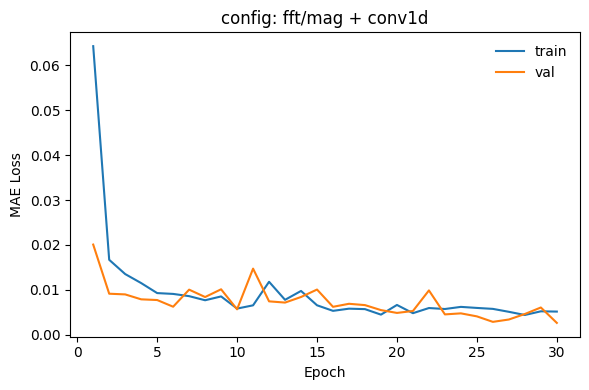

In [111]:
import matplotlib.pyplot as plt

if REPRESENTATION == "fft":
    cfg_title = f"config: fft/{INPUT_MODE} + {MODEL_TYPE}"
    if FFT_SEGMENTS_N > 1:
        cfg_title += f" (segments={FFT_SEGMENTS_N})"
else:
    cfg_title = f"config: raw/{INPUT_MODE} + {MODEL_TYPE}"

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="train")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss" if MODEL_TYPE == "mlp" else "MAE Loss")
plt.title(cfg_title)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



## 4. Test discrimination: FAN_ON vs each fault type


threshold: 0.0029130142647773027
Fault: Fan OFF
              precision    recall  f1-score   support

         0.0      0.369     0.831     0.511      1153
         1.0      0.000     0.000     0.000      1639

    accuracy                          0.343      2792
   macro avg      0.184     0.415     0.255      2792
weighted avg      0.152     0.343     0.211      2792

confusion_matrix: [[ 958  195]
 [1639    0]]
ROC AUC: 0.0001513414087556818


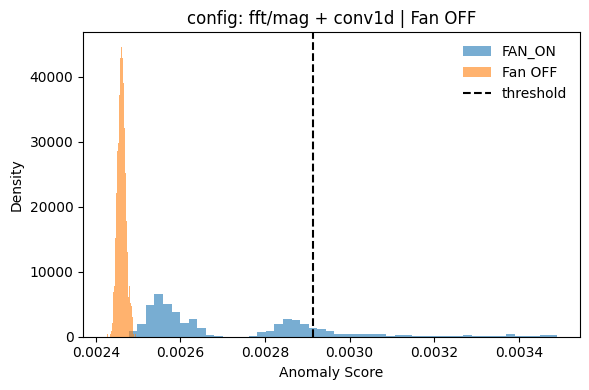

Fault: Blocked Flow
              precision    recall  f1-score   support

         0.0      0.282     0.831     0.421      1153
         1.0      0.636     0.122     0.205      2778

    accuracy                          0.330      3931
   macro avg      0.459     0.477     0.313      3931
weighted avg      0.532     0.330     0.269      3931

confusion_matrix: [[ 958  195]
 [2438  340]]
ROC AUC: 0.6488198376913888


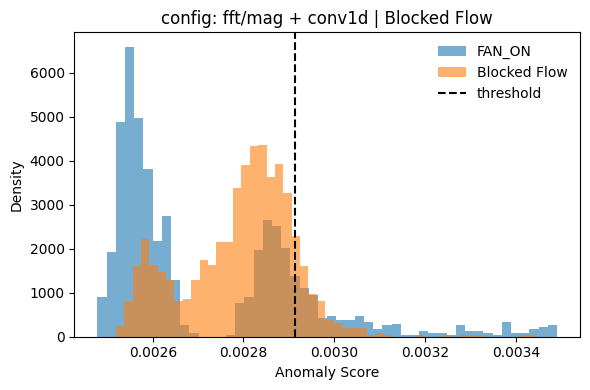

Fault: Blade Interference
              precision    recall  f1-score   support

         0.0      0.749     0.831     0.788      1153
         1.0      0.757     0.654     0.701       927

    accuracy                          0.752      2080
   macro avg      0.753     0.742     0.745      2080
weighted avg      0.752     0.752     0.749      2080

confusion_matrix: [[958 195]
 [321 606]]
ROC AUC: 0.8477121266130941


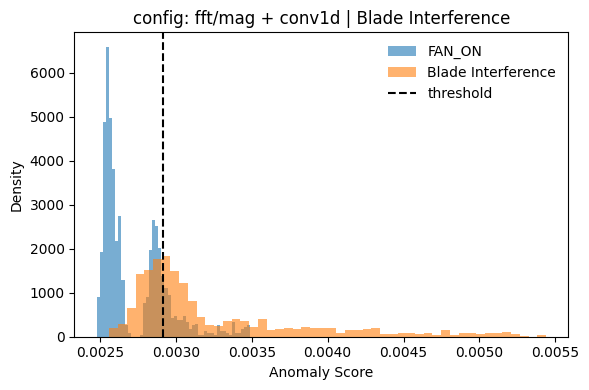

Fault: Mount Shock
              precision    recall  f1-score   support

         0.0      0.830     0.831     0.831      1153
         1.0      0.831     0.831     0.831      1158

    accuracy                          0.831      2311
   macro avg      0.831     0.831     0.831      2311
weighted avg      0.831     0.831     0.831      2311

confusion_matrix: [[958 195]
 [196 962]]
ROC AUC: 0.8452740991061839


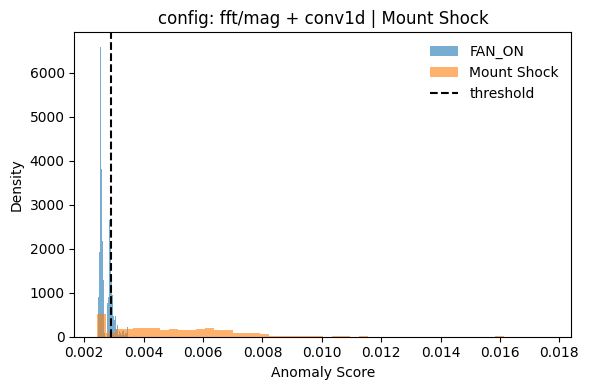

In [112]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

FAULT_TITLES = {
    "fan_off": "Fan OFF",
    "blocked_flow": "Blocked Flow",
    "blade_interference": "Blade Interference",
    "mount_shock": "Mount Shock",
}


def reconstruction_errors(model, loader, use_mae):
    model.eval()
    errs = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            recon = model(batch)
            if use_mae:
                err = (recon - batch).abs().reshape(batch.size(0), -1).mean(dim=1)
                power = batch.abs().reshape(batch.size(0), -1).mean(dim=1)
            else:
                err = (recon - batch).pow(2).reshape(batch.size(0), -1).mean(dim=1)
                power = batch.pow(2).reshape(batch.size(0), -1).mean(dim=1)

            if REL_ERROR:
                err = err / (power + 1e-8)
            errs.append(err.cpu().numpy())
    return np.concatenate(errs)


def pick_threshold(errors):
    if THRESH_METHOD == "max":
        return float(np.max(errors))
    if THRESH_METHOD == "quantile":
        return float(np.quantile(errors, THRESH_Q))
    raise ValueError(f"Unknown THRESH_METHOD={THRESH_METHOD}")


use_mae = MODEL_TYPE == "conv1d"
mode = dataset_mode()

segment_thresholds = None

if REPRESENTATION == "fft" and FFT_SEGMENTS_N > 1:
    thresholds = []
    scores_norm = None
    scores_faults = {name: None for name in test_fault_segments.keys()}

    for i, (x_tr, x_norm, model_i) in enumerate(
        zip(train_segments, test_norm_segments, models)
    ):
        train_loader = DataLoader(WindowDataset(x_tr, mode), batch_size=256, shuffle=False)
        norm_loader = DataLoader(WindowDataset(x_norm, mode), batch_size=256, shuffle=False)

        err_train = reconstruction_errors(model_i, train_loader, use_mae)
        thr = pick_threshold(err_train)
        thresholds.append(thr)

        err_norm = reconstruction_errors(model_i, norm_loader, use_mae)
        err_norm_n = err_norm / (thr + 1e-12)
        if scores_norm is None:
            scores_norm = err_norm_n
        else:
            scores_norm = np.maximum(scores_norm, err_norm_n)

        for fault_name, fault_segments in test_fault_segments.items():
            fault_loader = DataLoader(WindowDataset(fault_segments[i], mode), batch_size=256, shuffle=False)
            err_fault = reconstruction_errors(model_i, fault_loader, use_mae)
            err_fault_n = err_fault / (thr + 1e-12)
            if scores_faults[fault_name] is None:
                scores_faults[fault_name] = err_fault_n
            else:
                scores_faults[fault_name] = np.maximum(scores_faults[fault_name], err_fault_n)

    segment_thresholds = thresholds
    threshold = 1.0
    print("segment thresholds (train):", [round(t, 6) for t in thresholds])
else:
    val_loader_eval = DataLoader(WindowDataset(X_val, mode), batch_size=256, shuffle=False)
    test_norm_loader = DataLoader(WindowDataset(X_test_normal, mode), batch_size=256, shuffle=False)

    val_err = reconstruction_errors(model, val_loader_eval, use_mae)
    threshold = pick_threshold(val_err)

    scores_norm = reconstruction_errors(model, test_norm_loader, use_mae)
    scores_faults = {}
    for fault_name, x_fault in X_test_faults.items():
        fault_loader = DataLoader(WindowDataset(x_fault, mode), batch_size=256, shuffle=False)
        scores_faults[fault_name] = reconstruction_errors(model, fault_loader, use_mae)

print("threshold:", threshold)

for fault_name, scores_fault in scores_faults.items():
    y_true = np.concatenate([np.zeros_like(scores_norm), np.ones_like(scores_fault)])
    scores = np.concatenate([scores_norm, scores_fault])
    y_pred = (scores > threshold).astype(int)

    print(f"Fault: {FAULT_TITLES.get(fault_name, fault_name)}")
    print(classification_report(y_true, y_pred, digits=3))
    print("confusion_matrix:", confusion_matrix(y_true, y_pred))

    try:
        auc = roc_auc_score(y_true, scores)
        print("ROC AUC:", auc)
    except ValueError:
        print("ROC AUC: n/a (need both classes present)")

    plt.figure(figsize=(6, 4))
    plt.hist(scores_norm, bins=50, alpha=0.6, label="FAN_ON", density=True)
    plt.hist(scores_fault, bins=50, alpha=0.6, label=FAULT_TITLES.get(fault_name, fault_name), density=True)
    plt.axvline(threshold, color="k", linestyle="--", label="threshold")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Density")
    plt.title(f"{cfg_title} | {FAULT_TITLES.get(fault_name, fault_name)}")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
